
# UMBC Soccer — Expected Goals (xG) Match Analysis (2025)

**Author:** Jervon Drakes  
**Purpose:** Tactical performance analysis using Poisson-based expected goals modeling  

This notebook develops a match-level expected goals (xG) model for the UMBC men’s soccer team and applies it to analyze attacking performance during the 2025 season. The analysis focuses on separating chance creation from finishing variance and identifying contextual factors that influence goal scoring.


In [32]:
import pandas as pd
import numpy as np

matches = pd.read_csv("team_match_2025.csv")
matches.head()



,season,date,home_away,opponent,result,goals_for,goals_against,attendance,shots,shots_on_goal,yellow,red
0,2025.0,8/21/2025,Away,UNCW,W,2,1,1098,4,3,3,0
1,NaN,8/25/2025,Home,Saint Peter's,W,1,0,3281,13,5,1,0
2,NaN,8/29/2025,Home,Niagara,W,3,1,1185,11,4,3,0
3,NaN,9/1/2025,Home,Howard,W,1,0,1176,22,9,1,0
4,NaN,9/6/2025,Away,William & Mary,T,1,1,210,12,5,1,0


In [33]:
matches[["goals_for", "shots", "shots_on_goal"]].describe()




,goals_for,shots,shots_on_goal
count,17.000000,17.000000,17.000000
mean,1.176471,11.000000,4.705882
std,1.236694,4.596194,2.229482
min,0.000000,4.000000,1.000000
25%,0.000000,7.000000,3.000000
50%,1.000000,12.000000,5.000000
75%,2.000000,13.000000,6.000000
max,4.000000,22.000000,9.000000



## 2. Feature Engineering & Context Variables

To support tactical analysis, we construct additional features capturing match context and attacking efficiency:

- **home:** Indicator for home vs away matches.
- **shot_accuracy:** Ratio of shots on goal to total shots, serving as a proxy for chance quality.
- **shot_volume:** Total shots attempted.


These engineered variables allow the model to distinguish between shot volume, chance quality, and environmental(home/away) effects.


In [34]:
matches["home"] = (matches["home_away"] == "Home").astype(int)

matches["shot_accuracy"] = np.where(
    matches["shots"] > 0,
    matches["shots_on_goal"] / matches["shots"],
    0.0
)

matches["shot_volume"] = matches["shots"]

matches["discipline_diff"] = matches["yellow"] - matches["red"]

matches[[
    "date","opponent","home_away","home",
    "shots","shots_on_goal","shot_accuracy"
]].head()



,date,opponent,home_away,home,shots,shots_on_goal,shot_accuracy
0,8/21/2025,UNCW,Away,0,4,3,0.750000
1,8/25/2025,Saint Peter's,Home,1,13,5,0.384615
2,8/29/2025,Niagara,Home,1,11,4,0.363636
3,9/1/2025,Howard,Home,1,22,9,0.409091
4,9/6/2025,William & Mary,Away,0,12,5,0.416667


## 3. Baseline Poisson xG Model (Shots on Goal Only)

I first fit a simple Poisson regression model using only **shots on goal** as a predictor. This establishes a baseline expected goals (xG) estimate based purely on chance volume, allowing us to quantify finishing over- or under-performance.



In [35]:
from sklearn.linear_model import PoissonRegressor

X_base = matches[["shots_on_goal"]]
y = matches["goals_for"]

poisson_base = PoissonRegressor(alpha=0.0, max_iter=10000)
poisson_base.fit(X_base, y)

matches["xG"] = poisson_base.predict(X_base)

print("Intercept:", poisson_base.intercept_)
print("SOG coefficient:", poisson_base.coef_[0])



Intercept: -0.08773826379774635
SOG coefficient: 0.05182332762244441


In [36]:
matches[["date","opponent","goals_for","shots_on_goal","xG"]].head(10)



,date,opponent,goals_for,shots_on_goal,xG
0,8/21/2025,UNCW,2,3,1.070078
1,8/25/2025,Saint Peter's,1,5,1.186940
2,8/29/2025,Niagara,3,4,1.126995
3,9/1/2025,Howard,1,9,1.460344
4,9/6/2025,William & Mary,1,5,1.186940
5,9/12/2025,Old Dominion,0,2,1.016036
6,9/16/2025,Navy,0,6,1.250073
7,9/20/2025,George Mason,0,8,1.386591
8,9/27/2025,Vermont,0,4,1.126995
9,10/4/2025,Bryant,1,3,1.070078


## 4. Finishing Performance: Goals vs xG

Using the baseline xG model, we compute **finishing difference**:

$
\text{finishing\_diff} = \text{goals} - \text{xG}
$\]

This metric identifies matches where UMBC overperformed or underperformed relative to shot quality. I also compute **finishing Z-scores** to standardize finishing performance across the season.


In [37]:
matches["finishing_diff"] = matches["goals_for"] - matches["xG"]

matches["finishing_z"] = (
    matches["finishing_diff"] - matches["finishing_diff"].mean()
) / matches["finishing_diff"].std()

matches[["date","opponent","goals_for","xG","finishing_diff","finishing_z"]].head(10)


,date,opponent,goals_for,xG,finishing_diff,finishing_z
0,8/21/2025,UNCW,2,1.070078,0.929922,0.754849
1,8/25/2025,Saint Peter's,1,1.186940,-0.186940,-0.151821
2,8/29/2025,Niagara,3,1.126995,1.873005,1.520445
3,9/1/2025,Howard,1,1.460344,-0.460344,-0.373770
4,9/6/2025,William & Mary,1,1.186940,-0.186940,-0.151821
5,9/12/2025,Old Dominion,0,1.016036,-1.016036,-0.824882
6,9/16/2025,Navy,0,1.250073,-1.250073,-1.014873
7,9/20/2025,George Mason,0,1.386591,-1.386591,-1.125699
8,9/27/2025,Vermont,0,1.126995,-1.126995,-0.914959
9,10/4/2025,Bryant,1,1.070078,-0.070078,-0.056952


In [38]:
matches[[
    "date","opponent","home_away",
    "goals_for","xG","finishing_diff","finishing_z"
]].sort_values("finishing_diff", ascending=False)



,date,opponent,home_away,goals_for,xG,finishing_diff,finishing_z
14,10/31/2025,Binghamton,Home,4,1.250073,2.749927,2.232332
2,8/29/2025,Niagara,Home,3,1.126995,1.873005,1.520445
12,10/21/2025,George Washington,Away,3,1.250073,1.749927,1.420531
13,10/25/2025,Umass Lowell,Away,2,1.016036,0.983964,0.798721
0,8/21/2025,UNCW,Away,2,1.070078,0.929922,0.754849
9,10/4/2025,Bryant,Home,1,1.070078,-0.070078,-0.056952
4,9/6/2025,William & Mary,Away,1,1.186940,-0.186940,-0.151821
1,8/25/2025,Saint Peter's,Home,1,1.186940,-0.186940,-0.151821
10,10/11/2025,New Hampshire,Home,1,1.250073,-0.250073,-0.203072
15,11/4/2025,NJIT,Away,1,1.316564,-0.316564,-0.257049


## 5. Visual Validation: Goals vs xG Scatter

A scatter plot of actual goals versus expected goals provides a diagnostic visualization. Matches above the diagonal represent positive finishing variance, while those below suggest underperformance.



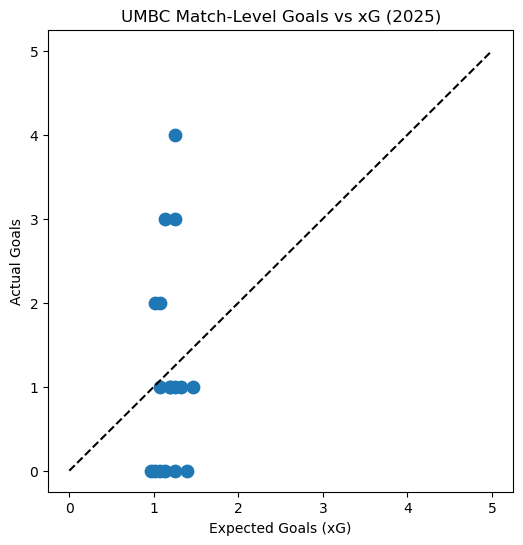

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(matches["xG"], matches["goals_for"], s=80)
plt.plot([0,5],[0,5], linestyle="--", color="black")
plt.xlabel("Expected Goals (xG)")
plt.ylabel("Actual Goals")
plt.title("UMBC Match-Level Goals vs xG (2025)")
plt.show()



## 6. Contextual Poisson xG Model (Shot Quality + Match Context)
I extend the baseline model by incorporating additional contextual predictors:

- **shots_on_goal:** Chance volume
- **home:** Home-field advantage
- **shot_accuracy:** Proxy for chance quality

This produces a more refined expected goals estimate (**xG_context**), accounting for both opportunity and environment.



In [40]:
X_ctx = matches[[
    "shots_on_goal",
    "home",
    "shot_accuracy"
]]

poisson_context = PoissonRegressor(alpha=0.0, max_iter=10000)
poisson_context.fit(X_ctx, y)

matches["xG_context"] = poisson_context.predict(X_ctx)

print("Intercept:", poisson_context.intercept_)
print("Coefficients:", dict(zip(X_ctx.columns, poisson_context.coef_)))



Intercept: -0.3325153955105319
Coefficients: {'shots_on_goal': 0.016657867158513886, 'home': 0.34771916000353625, 'shot_accuracy': 0.544936619809622}


In [41]:
matches[[
    "date","opponent","home_away",
    "goals_for","xG","xG_context",
    "shot_accuracy","shots_on_goal"
]].head(10)



,date,opponent,home_away,goals_for,xG,xG_context,shot_accuracy,shots_on_goal
0,8/21/2025,UNCW,Away,2,1.070078,1.134464,0.750000,3
1,8/25/2025,Saint Peter's,Home,1,1.186940,1.360815,0.384615,5
2,8/29/2025,Niagara,Home,3,1.126995,1.323122,0.363636,4
3,9/1/2025,Howard,Home,1,1.460344,1.474108,0.409091,9
4,9/6/2025,William & Mary,Away,1,1.186940,0.978075,0.416667,5
5,9/12/2025,Old Dominion,Home,0,1.016036,1.258808,0.333333,2
6,9/16/2025,Navy,Away,0,1.250073,1.066807,0.545455,6
7,9/20/2025,George Mason,Home,0,1.386591,1.523385,0.500000,8
8,9/27/2025,Vermont,Away,0,1.126995,1.046560,0.571429,4
9,10/4/2025,Bryant,Home,1,1.070078,1.199554,0.214286,3


## 7. Contextual Finishing Analysis
I compute contextual finishing performance as:

$
\text{finishing\_diff\_ctx} = \text{goals} - \text{xG\_context}
$

This metric isolates finishing performance after controlling for both shot volume and quality.


In [42]:
matches["finishing_diff_ctx"] = matches["goals_for"] - matches["xG_context"]

matches["finishing_z_ctx"] = (
    matches["finishing_diff_ctx"] - matches["finishing_diff_ctx"].mean()
) / matches["finishing_diff_ctx"].std()

matches[["date","opponent","goals_for","xG_context","finishing_diff_ctx","finishing_z_ctx"]].head(10)


,date,opponent,goals_for,xG_context,finishing_diff_ctx,finishing_z_ctx
0,8/21/2025,UNCW,2,1.134464,0.865536,0.710083
1,8/25/2025,Saint Peter's,1,1.360815,-0.360815,-0.296022
2,8/29/2025,Niagara,3,1.323122,1.676878,1.375712
3,9/1/2025,Howard,1,1.474108,-0.474108,-0.388968
4,9/6/2025,William & Mary,1,0.978075,0.021925,0.017980
5,9/12/2025,Old Dominion,0,1.258808,-1.258808,-1.032739
6,9/16/2025,Navy,0,1.066807,-1.066807,-0.875221
7,9/20/2025,George Mason,0,1.523385,-1.523385,-1.249800
8,9/27/2025,Vermont,0,1.046560,-1.046560,-0.858610
9,10/4/2025,Bryant,1,1.199554,-0.199554,-0.163722


## 8. Diagnostic OLS Regression (Explaining Finishing Variance)

To assess whether finishing over- or under-performance is systematically explained by match context, I estimate an Ordinary Least Squares (OLS) regression using finishing difference as the dependent variable.

This step is diagnostic rather than predictive, helping determine whether finishing is primarily driven by tactical factors or stochastic variation.


In [43]:
import statsmodels.api as sm

X_perf = matches[[
    "home",
    "shot_accuracy",
    "shots_on_goal"
]]
X_perf = sm.add_constant(X_perf)

y_perf = matches["finishing_diff_ctx"]

model_perf = sm.OLS(y_perf, X_perf).fit()
print(model_perf.summary())


                            OLS Regression Results                            
Dep. Variable:     finishing_diff_ctx   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.231
Method:                 Least Squares   F-statistic:                 1.847e-11
Date:                Tue, 27 Jan 2026   Prob (F-statistic):               1.00
Time:                        12:10:49   Log-Likelihood:                -26.972
No. Observations:                  17   AIC:                             61.94
Df Residuals:                      13   BIC:                             65.28
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          6.853e-06      1.297   5.28e-06

C:\Users\jdrakes1\AppData\Local\anaconda3\envs\soccer\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


## 9. Summary of Findings

This analysis yields several important insights into UMBC’s attacking performance during the 2025 season:

- **Chance creation is the primary systematic driver of scoring.**  
  The Poisson expected goals (xG) models demonstrate that shots on goal, shot accuracy, and home advantage strongly influence expected scoring output. These variables explain how many goals UMBC *should* score based on the quantity and quality of chances created, indicating that chance generation is a repeatable and tactically controllable process.

- **Finishing performance largely reflects stochastic variation rather than systematic effects.**  
  The diagnostic OLS regression of finishing difference (goals − xG) against match context variables produces an R² value effectively equal to zero, with no statistically significant predictors. This indicates that once chance quality and volume are accounted for, the remaining variation in goal scoring is largely driven by randomness, situational factors, and execution noise rather than stable tactical patterns.

- **Short-term scoring fluctuations should be interpreted with caution.**  
  Because finishing deviations are largely unpredictable in small samples, short-term goal droughts or scoring streaks should not be overinterpreted as meaningful changes in attacking quality. Instead, performance evaluation should prioritize expected goals and chance creation metrics.

- **xG provides a stable framework for tactical assessment.**  
  By separating systematic chance generation from finishing variance, the xG framework enables a more reliable evaluation of team attacking performance, supporting data-driven tactical adjustments and strategic planning.

- **Coaching emphasis should prioritize sustainable attacking processes.**  
  Given the stochastic nature of finishing, tactical interventions are more likely to yield long-term benefits by improving buildup play, chance quality, and shot volume rather than attempting to directly optimize short-term finishing outcomes.

Overall, these findings align with modern football analytics research, reinforcing the central role of chance creation as the key determinant of sustainable scoring performance.
